# Schematic Figure 1

This figure combines a real-space random line field, the corresponding isotropic line-density correlation, and a direct real-space estimate of the contour-distance-dependent end-to-end displacement. Panel (b) uses the saved Gaussian-radial calculation from `smpl/rw_line_general.ipynb`. Panel (c) traces one \(S_{12}\) vortex-line family with the same saved relative radial-spectrum width, resamples its ordered polylines uniformly in contour distance, and averages \(\left|\mathbf R(s_0+s)-\mathbf R(s_0)\right|^2\) over all eligible origins.

In [1]:
import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import rw_line_network as rwn
import rw_line_scattering as rws

rwn = importlib.reload(rwn)
rws = importlib.reload(rws)

PROJECT_ROOT = Path.cwd().resolve()
SCHEMATIC_IMAGE_PATH = PROJECT_ROOT / "schematic_linefield.png"
GENERAL_DATA_PATH = PROJECT_ROOT / "smpl" / "rw_line_general_output" / "general_data.npz"
FIGURE_PATH = PROJECT_ROOT / "schematic_fig_1.png"

if not SCHEMATIC_IMAGE_PATH.exists():
    raise FileNotFoundError(f"Missing schematic image: {SCHEMATIC_IMAGE_PATH}")
if not GENERAL_DATA_PATH.exists():
    raise FileNotFoundError(f"Missing rw_line_general output: {GENERAL_DATA_PATH}")

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.alpha": 0.22,
})

## Load the Gaussian-radial line correlation

The saved data are generated by `rw_line_general.ipynb` using \(k_0=1\) and a Gaussian-radial spectrum. The width is read from the saved calculation.

In [2]:
general_data = np.load(GENERAL_DATA_PATH)
r_grid = np.asarray(general_data["r_grid"], dtype=float)
C_L = np.asarray(general_data["C_L"], dtype=float)
k_eff_general = float(general_data["k_eff"])
rho0_general = float(general_data["rho0"])
r_sigma_general = float(general_data["r_sigma_k"])
# r_sigma_general = 0.1

print(f"[C_L] k_eff={k_eff_general:.6g}, r_sigma_k={r_sigma_general:.3g}, rho_L={rho0_general:.6g}")

[C_L] k_eff=1.005, r_sigma_k=0.1, rho_L=0.107166


## Direct real-space estimate of the end-to-end displacement

`RUN_REAL_SPACE_SAMPLING` can be set to `False` after a calculation if only the assembled figure needs to be redrawn. The trajectory field uses the same Gaussian-radial width as panel (b); its absolute wave number is chosen so that the finite numerical box contains several line-field correlation lengths.

In [3]:
RUN_REAL_SPACE_SAMPLING = True

# The relative spectrum is matched to rw_line_general.ipynb.
FIELD_GRID_SIZE = 64
FIELD_K0 = 5.0
FIELD_R_SIGMA_K = r_sigma_general
FIELD_NUM_MODES = 256
FIELD_RANDOM_SEED = 894894
CHAIN_POINT_SPACING = 0.35
CHAIN_MAX_S_OVER_K = 100.0
CHAIN_NUM_LAGS = 60
CHAIN_MIN_PAIR_COUNT = 100

def contour_r2_from_polylines(polylines, spacing, k_eff, max_s_over_k, num_lags):
    max_lag = max(1, int(np.floor(max_s_over_k/(k_eff*spacing))))
    lags = np.unique(np.round(np.geomspace(1, max_lag, int(num_lags))).astype(int))
    sums = np.zeros(lags.size, dtype=float)
    counts = np.zeros(lags.size, dtype=int)
    for cell in polylines:
        points = rws._sample_line_cell_by_arclength(cell, spacing)
        # The final endpoint can be at a shorter residual interval; omit it so
        # every retained pair is separated by an integer multiple of spacing.
        if points.shape[0] > 1:
            points = points[:-1]
        for index, lag in enumerate(lags):
            if points.shape[0] <= lag:
                continue
            displacement = points[lag:] - points[:-lag]
            squared_distance = np.einsum("ij,ij->i", displacement, displacement)
            sums[index] += float(np.sum(squared_distance))
            counts[index] += squared_distance.size
    valid = counts > 0
    return lags[valid]*spacing, sums[valid]/counts[valid], counts[valid]

if RUN_REAL_SPACE_SAMPLING:
    rwn.GRID_SIZE = FIELD_GRID_SIZE
    rwn.NUM_BLOCK = 2
    rwn.BLOCK_OVERLAP = 0
    rwn.RANDOM_SEED = FIELD_RANDOM_SEED
    rwn.NUM_MODES = (FIELD_NUM_MODES, FIELD_NUM_MODES, FIELD_NUM_MODES)
    rwn.K_DISTRIBUTION = "gaussian_radial"
    rwn.K0 = (FIELD_K0, FIELD_K0, FIELD_K0)
    rwn.r_SIGMA_K = (FIELD_R_SIGMA_K, FIELD_R_SIGMA_K, FIELD_R_SIGMA_K)
    rwn.SHARED_K_VECTORS = False
    rwn.COUPLE_PHI2_PHI3 = False
    rwn.USE_VORTEX_TRACING = True
    rwn.VORTEX_FACE_PREFILTER = True
    rwn.SMOOTH_VORTEX_LINES = True
    rwn.VORTEX_SMOOTHING_SCALE = 2

    full_structure = rws.build_line_structure(
        line_sample_spacing=CHAIN_POINT_SPACING,
        include_crosslinks=False,
        print_timing=True,
        timing_label="schematic end-to-end sampling",
    )
    single_chain = rws.as_single_s12_structure(
        full_structure,
        line_sample_spacing=CHAIN_POINT_SPACING,
    )
    trajectory_polylines = rws._line_cells(single_chain.s12_lines)
    k_eff_field = (
        2.0*np.pi*FIELD_K0*np.sqrt(1.0 + FIELD_R_SIGMA_K**2)/FIELD_GRID_SIZE
    )
    contour_s, contour_r2, contour_pair_count = contour_r2_from_polylines(
        trajectory_polylines,
        CHAIN_POINT_SPACING,
        k_eff_field,
        CHAIN_MAX_S_OVER_K,
        CHAIN_NUM_LAGS,
    )
    keep = contour_pair_count >= CHAIN_MIN_PAIR_COUNT
    contour_s = contour_s[keep]
    contour_r2 = contour_r2[keep]
    contour_pair_count = contour_pair_count[keep]
    print(f"[trajectory] traced polylines={len(trajectory_polylines)}, k_eff={k_eff_field:.6g}")
    print(f"[trajectory] retained contour separations={contour_s.size}, pair counts={contour_pair_count.min()} to {contour_pair_count.max()}")
else:
    raise RuntimeError("Set RUN_REAL_SPACE_SAMPLING=True before assembling the figure.")

schematic end-to-end sampling: fields 34.325s; vortex trace 4.075s; smoothing 5.101s; line point sampling 0.580s; crosslinks 0.001s
schematic end-to-end sampling: sampled points 236776 line segments 310241; (S12 119802, S13 116974, crosslinks 0); structure total 44.086s
[trajectory] traced polylines=796, k_eff=0.493322
[trajectory] retained contour separations=48, pair counts=18609 to 118210


## Assemble the three-panel figure

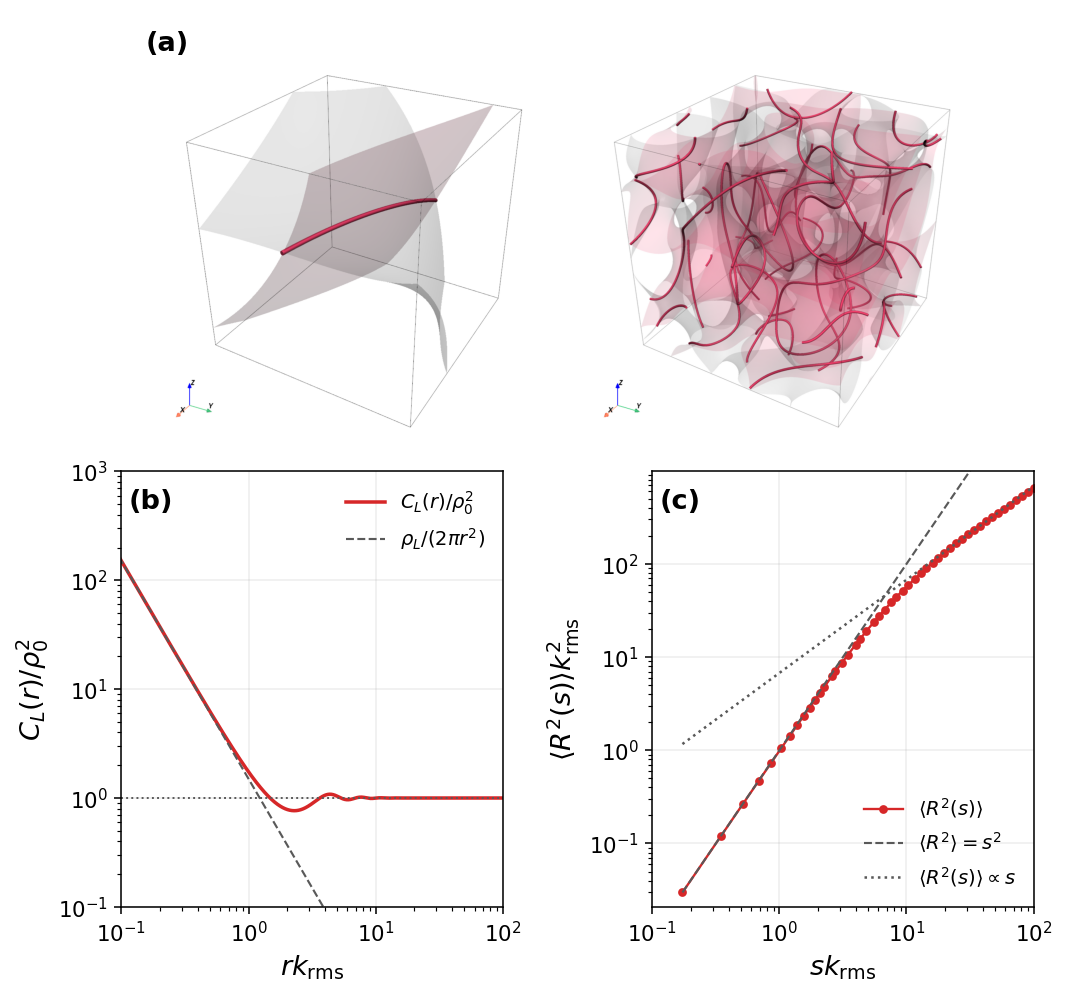

[saved] C:\Users\ccu\Documents\codex_projects\project_randomcxl\schematic_fig_1.png


In [15]:
schematic_image = plt.imread(SCHEMATIC_IMAGE_PATH)

fig, axes = plt.subplot_mosaic(
    [["a", "a"], ["b", "c"]],
    figsize=(7.5, 7.0),
    constrained_layout=True,
)

# (a) Supplied line-field schematic.
axes["a"].imshow(schematic_image)
axes["a"].set_axis_off()
axes["a"].text(
    0.0, 0.96, "(a)", transform=axes["a"].transAxes,
    ha="left", va="top", fontsize=14, fontweight="bold", color="black",
)

# (b) Isotropic line-density correlation from rw_line_general.
x_cl = r_grid*k_eff_general
y_cl = C_L/(rho0_general**2)
local_line_limit = rho0_general/(2.0*np.pi*r_grid**2)/(rho0_general**2)
axes["b"].loglog(x_cl, y_cl, color="C3", lw=1.8, label=r"$C_L(r)/\rho_0^2$")
axes["b"].loglog(
    x_cl, local_line_limit, "--", color="0.35", lw=1.1,
    label=r"$\rho_L/(2\pi r^2)$",
)
axes["b"].axhline(
    1.0, color="0.35", ls=":", lw=1.0,
    # label=r"$\rho_0^2/(3\pi k_{\rm{rms}}^2)^2$",
)
axes["b"].set(
    xlabel=r"$r k_{\rm{rms}}$",
    ylabel=r"$C_L(r)/\rho_0^2$",
)
axes["b"].legend(fontsize=10, frameon=False, loc="best")
axes["b"].text(0.02, 0.96, "(b)", transform=axes["b"].transAxes, ha="left", va="top", fontsize=14, fontweight="bold")
axes["b"].set_xlim(1e-1, 1e2)
axes["b"].set_ylim(1e-1, 1e3)

# (c) Direct contour-displacement estimate from the sampled S12 trajectories.
x_r2 = contour_s*k_eff_field
y_r2 = contour_r2*k_eff_field**2
axes["c"].loglog(x_r2, y_r2, "o-", color="C3", ms=3.5, lw=1.2, label=r"$\langle R^2(s)\rangle$")
axes["c"].loglog(
    x_r2, x_r2**2, "--", color="0.35", lw=1.1,
    label=r"$\langle R^2\rangle=s^2$",
)
HIGH_S_TANGENT_RANGE = (20.0, 60.0)
high_s_mask = (x_r2 >= HIGH_S_TANGENT_RANGE[0]) & (x_r2 <= HIGH_S_TANGENT_RANGE[1])
if np.count_nonzero(high_s_mask) < 3:
    raise RuntimeError("Not enough high-s points to construct the asymptotic tangent.")
high_s_tangent_slope = float(
    np.dot(x_r2[high_s_mask], y_r2[high_s_mask])
    / np.dot(x_r2[high_s_mask], x_r2[high_s_mask])
)
axes["c"].loglog(
    x_r2, high_s_tangent_slope*x_r2, ":", color="0.35", lw=1.3,
    label=r"$\langle R^2(s)\rangle\propto s$",
)
axes["c"].set(
    xlabel=r"$s k_{\rm{rms}}$",
    ylabel=r"$\langle R^2(s)\rangle k_{\rm{rms}}^2$",
    xlim=(max(x_r2.min()*0.9, 1e-2), x_r2.max()*1.1),
    ylim=(max(y_r2.min()*0.7, 1e-3), y_r2.max()*1.5),
)
axes["c"].legend(fontsize=10, frameon=False, loc="best")
axes["c"].text(0.02, 0.96, "(c)", transform=axes["c"].transAxes, ha="left", va="top", fontsize=14, fontweight="bold")
axes["c"].set_xlim(1e-1, 1e2)

for key in ("b", "c"):
    axes[key].tick_params(axis="both", which="both", labelsize=11)
    axes[key].xaxis.label.set_size(14)
    axes[key].yaxis.label.set_size(14)

fig.savefig(FIGURE_PATH, bbox_inches="tight")
plt.show()
print(f"[saved] {FIGURE_PATH}")